# K-Nearest Neighbors (KNN): Student Pass/Fail Prediction

## Problem
Predict whether a student will **pass (1)** or **fail (0)** from study hours, attendance and previous score.

## Objective
Understand how KNN predicts by looking at **similar students**, why **feature scaling** matters for it, and how to pick the best value of **K** without cheating on the test set.

**Dataset:** `data/student_pass_fail.csv` (300 rows). The data is **synthetic** (randomly generated with a fixed seed by `data/generate_data.py`) for learning purposes. It does not describe real students.

| Column | Meaning |
|--------|---------|
| `study_hours` | Daily study hours (0 to 10) |
| `attendance_pct` | Attendance percentage (50 to 100) |
| `previous_score` | Score in the previous exam (20 to 100) |
| `passed` | 1 = passed, 0 = failed (target) |

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load the Dataset and Split

In [2]:
from pathlib import Path

def find_data(filename):
    """Find data/<filename> by searching this notebook's folder and its parent folders."""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/{filename}. Open this notebook from inside the project folder."
    )


In [3]:
df = pd.read_csv(find_data("student_pass_fail.csv"))
features = ["study_hours", "attendance_pct", "previous_score"]
X = df[features]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Shape:", df.shape, "| Training rows:", len(X_train), "| Test rows:", len(X_test))

Shape: (300, 4) | Training rows: 240 | Test rows: 60


## 3. How KNN Works

KNN has **no training step**. To predict for a new student, it:

1. Measures the distance from the new student to every student in the training data.
2. Picks the **K closest** students (the neighbors).
3. Lets them **vote**: if most of them passed, the prediction is Pass.

Because it is based on **distance**, features with large numbers (like a score out of 100) can overpower features with small numbers (like study hours from 0 to 10).

## 4. Why Feature Scaling Matters

`StandardScaler` rescales every feature to the same range (mean 0, spread 1) so that each one counts equally. We compare KNN with and without scaling, using the same K.

In [4]:
knn_raw = KNeighborsClassifier(n_neighbors=11).fit(X_train, y_train)
knn_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11)).fit(X_train, y_train)

print(f"Accuracy WITHOUT scaling: {knn_raw.score(X_test, y_test):.3f}")
print(f"Accuracy WITH scaling   : {knn_scaled.score(X_test, y_test):.3f}")

Accuracy WITHOUT scaling: 0.717
Accuracy WITH scaling   : 0.883


Scaling gives a large improvement. Without it, `previous_score` and `attendance_pct` (large numbers) dominate the distance and `study_hours`, the most useful feature, is almost ignored.

## 5. Choose K with Cross-Validation

- **Small K** (like 1) follows noise and overfits.
- **Large K** over-smooths and can miss real patterns.

We test odd values of K from 1 to 25 using **5-fold cross-validation on the training data only**. The test set stays untouched, so the final score is honest.

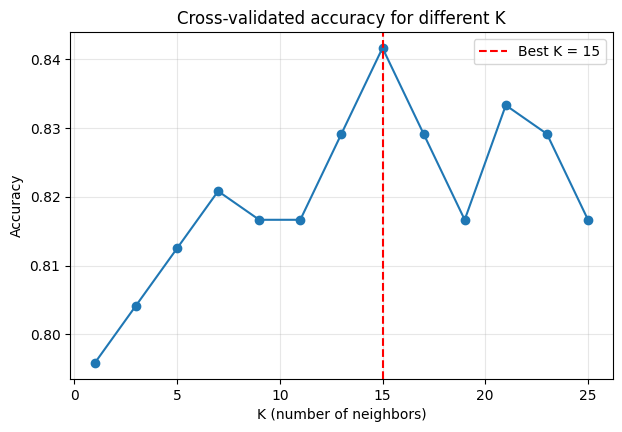

Best K: 15 | CV accuracy: 0.842


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values = list(range(1, 26, 2))
cv_scores = []
for k in k_values:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    cv_scores.append(cross_val_score(pipe, X_train, y_train, cv=cv).mean())

best_k = k_values[int(np.argmax(cv_scores))]

plt.figure(figsize=(7, 4.5))
plt.plot(k_values, cv_scores, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.title("Cross-validated accuracy for different K")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Best K:", best_k, "| CV accuracy:", round(max(cv_scores), 3))

## 6. Final Model and Evaluation on Test Data

In [6]:
model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
model.fit(X_train, y_train)
pred = model.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, pred):.3f}\n")
print(classification_report(y_test, pred, target_names=["Fail", "Pass"]))

Test accuracy: 0.867

              precision    recall  f1-score   support

        Fail       0.84      0.94      0.89        33
        Pass       0.91      0.78      0.84        27

    accuracy                           0.87        60
   macro avg       0.88      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



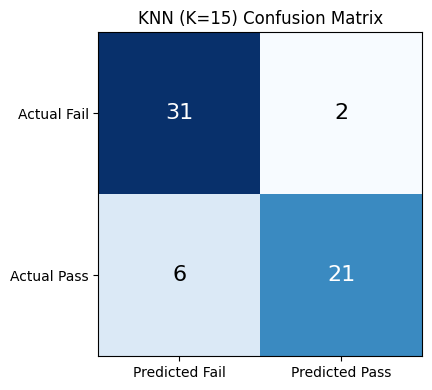

In [7]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], ["Predicted Fail", "Predicted Pass"])
    ax.set_yticks([0, 1], ["Actual Fail", "Actual Pass"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(y_test, pred, f"KNN (K={best_k}) Confusion Matrix")

## 7. Predict for a New Student

In [8]:
student = pd.DataFrame([[6, 85, 65]], columns=features)   # 6 hours, 85% attendance, previous score 65
prob_fail, prob_pass = model.predict_proba(student)[0]

print(f"Probability of failing : {prob_fail:.1%}")
print(f"Probability of passing : {prob_pass:.1%}")
print("Prediction:", "Pass" if model.predict(student)[0] == 1 else "Fail")

Probability of failing : 6.7%
Probability of passing : 93.3%
Prediction: Pass


## Conclusion

- Scaling is essential for KNN: accuracy at K = 11 jumped from about **72% to 88%** just by scaling the features.
- Cross-validation picked **K = 15**, which gives a stable result with a test accuracy of about **87%**.
- Precision for Pass is high (about 91%), but recall is about 78%: the model misses some students who actually passed.
- KNN stores all the training data and measures distance to every row at prediction time, so it becomes slow on very large datasets.
- Its predicted probability is simply the share of the K neighbors that passed, so it is coarser than the smooth probability from logistic regression.